# AtmoSound – Model Training Pipeline

Continues from **AtmoSound_Preprocessing.ipynb**.

- Ridge Regression: closed-form normal equations (`fit_ridge_closed_form`)
- Neural Network: manual forward/backward with NumPy
- K-Means: `initialize_random_centroids` / `fit_kmeans` / `predict_cluster` / `euclidean`
- Metrics: `mse_func`, `rmse_func`, `cosine_similarity_score`, `print_info`

### Methods
| Method | Type |
|---|---|
| Ridge Regression | Regression |
| Neural Network (ANN) | Artificial Neural Network |
| K-Means | Clustering (interpretive) |

### Inputs & Outputs
- **Input:** d-dimensional venue feature vector (one-hot + TF-IDF/SVD + boolean flags)
- **Output:** 7-dimensional audio profile [danceability, energy, acousticness, valence, instrumentalness, liveness, speechiness]

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import os
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

AUDIO_FEATURES = [
    "danceability", "energy", "acousticness", "valence",
    "instrumentalness", "liveness", "speechiness"
]

os.makedirs("model_artifacts", exist_ok=True)
print("Setup complete.")

Setup complete.


## 2. Load Preprocessed Data

In [2]:
data = np.load("pipeline_artifacts/model_ready_data.npz", allow_pickle=True)
X_train = data["X_train"]
y_train = data["y_train"]
X_val   = data["X_val"]
y_val   = data["y_val"]
X_test  = data["X_test"]
y_test  = data["y_test"]
feature_names = list(data["feature_names"])

genre_profiles  = pd.read_csv("pipeline_artifacts/genre_profiles.csv", index_col=0)
genre_centroids = genre_profiles[AUDIO_FEATURES].values
genre_names     = list(genre_profiles.index)

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")
print(f"Features:   {X_train.shape[1]}")
print(f"Targets:    {y_train.shape[1]} audio dimensions")
print(f"Genres:     {len(genre_names)}")

Train:      (2853, 279)
Validation: (714, 279)
Test:       (917, 279)
Features:   279
Targets:    7 audio dimensions
Genres:     112


## 3. Evaluation Metrics

Two primary metrics used for model comparison and deployment selection.

### Metric 1: MSE
$$MSE = \frac{1}{n}\sum_{i=1}^{n}\frac{1}{7}\sum_{j=1}^{7}(y_{ij} - \hat{y}_{ij})^2$$
Since all audio features are normalised to [0,1], MSE values are directly comparable
across dimensions and models. Models must fall below the mean-prediction baseline to
demonstrate learned signal.

### Metric 2: Cosine Similarity
$$CosSim(y, \hat{y}) = \frac{y \cdot \hat{y}}{\|y\| \cdot \|\hat{y}\|}$$
Liveness (σ = 0.045) and speechiness (σ = 0.030) have low variance across genres,
inflating MSE for directionally correct predictions. Cosine similarity evaluates profile
shape independent of magnitude, providing a more faithful atmospheric fit indicator.

In [3]:
def mse_func(y_true, y_pred):
    """
    Mean Squared Error averaged over all samples and all 7 audio dimensions.

    Input:
        - y_true: true targets  (N, 7)
        - y_pred: predicted     (N, 7)
    Output:
        - error: MSE scalar
    """
    error = np.mean((y_true - y_pred) ** 2)
    return float(error)


def rmse_func(y_true, y_pred):
    """
    Root Mean Squared Error.

    Input:
        - y_true: true targets
        - y_pred: predicted targets
    Output:
        - error: RMSE scalar
    """
    num_examples = len(y_true)
    error = np.sqrt(np.sum(np.power(y_true - y_pred, 2)) / num_examples)
    return error


def mae_func(y_true, y_pred):
    """
    Mean Absolute Error.

    Input:
        - y_true: true targets
        - y_pred: predicted targets
    Output:
        - error: MAE scalar
    """
    error = np.sum(np.abs(y_true - y_pred)) / y_true.shape[0]
    return error


def r2_score(y_true, y_pred):
    """
    Coefficient of Determination R2 = 1 - RSS/TSS.

    Input:
        - y_true: true targets
        - y_pred: predicted targets
    Output:
        - r2: scalar
    """
    tss = np.sum(np.power(y_true - np.mean(y_true), 2))
    rss = np.sum(np.power(y_true - y_pred, 2))
    return 1 - (rss / tss)


def cosine_similarity_score(y_true, y_pred):
    """
    Average cosine similarity between predicted and true audio profiles.

    Input:
        - y_true: (N, 7) true audio profiles
        - y_pred: (N, 7) predicted audio profiles
    Output:
        - score: scalar in [-1, 1]
    """
    dot    = np.sum(y_true * y_pred, axis=1)
    norm_t = np.linalg.norm(y_true, axis=1)
    norm_p = np.linalg.norm(y_pred, axis=1)
    denom  = norm_t * norm_p
    denom  = np.where(denom == 0, 1.0, denom)
    return float(np.mean(dot / denom))


def print_info(mode, y_true, y_pred, print_results=True):
    """
    Print MSE, RMSE, and CosSim for a split.

    Input:
        - mode: label string
        - y_true, y_pred: arrays
        - print_results: whether to print
    Output:
        - (mse, rmse, cos_sim) tuple
    """
    mse_val  = mse_func(y_true, y_pred)
    rmse_val = rmse_func(y_true, y_pred)
    cos_val  = cosine_similarity_score(y_true, y_pred)
    if print_results:
        print(f"{mode}: MSE={mse_val:.5f}  RMSE={rmse_val:.5f}  CosSim={cos_val:.4f}")
    return mse_val, rmse_val, cos_val


print("Metrics defined: mse_func, rmse_func, mae_func, r2_score, cosine_similarity_score, print_info")

Metrics defined: mse_func, rmse_func, mae_func, r2_score, cosine_similarity_score, print_info


## 4. Baselines

Models must beat the mean-prediction baseline to demonstrate learned signal.

In [4]:
y_mean    = y_train.mean(axis=0)
mean_pred = np.tile(y_mean, (X_val.shape[0], 1))

rng       = np.random.RandomState(42)
rand_pred = genre_centroids[rng.choice(len(genre_names), X_val.shape[0])]

print("Baseline performance on VALIDATION set:")
print_info("Mean-prediction baseline", y_val, mean_pred)
print_info("Random-genre baseline",    y_val, rand_pred)

BASELINE_MSE  = mse_func(y_val, mean_pred)
BASELINE_RMSE = rmse_func(y_val, mean_pred)
print(f"\nTarget: MSE < {BASELINE_MSE:.5f}  RMSE < {BASELINE_RMSE:.5f}")

Baseline performance on VALIDATION set:
Mean-prediction baseline: MSE=0.00411  RMSE=0.16967  CosSim=0.9874
Random-genre baseline: MSE=0.03188  RMSE=0.47242  CosSim=0.9168

Target: MSE < 0.00411  RMSE < 0.16967


## 5. Ridge Regression

### Problem Formulation
Given venue feature matrix $X \in \mathbb{R}^{N \times d}$ and audio target matrix
$Y \in \mathbb{R}^{N \times 7}$, Ridge minimises the regularised least-squares objective:

$$L(W) = \|XW - Y\|^2_F + \lambda\|W\|^2_F$$

The closed-form solution solves this in a single step:

$$W^* = (X^TX + \lambda I)^{-1}X^TY$$

Implemented using `np.linalg.solve` for numerical stability over explicit matrix inversion.
The bias term is excluded from regularisation by setting the corresponding diagonal entry to zero.

### Why Ridge is well-suited
- Feature space is wide (>100 dims) with correlated one-hot/TF-IDF features — L2 shrinks correlated coefficients without zeroing them
- Closed-form solution yields the exact optimum at this dataset scale (N=2853, d=279)
- Single matrix multiply at inference — low latency for Streamlit deployment
- Weight matrix directly interpretable: which venue features drive each audio dimension

### Inputs & Outputs
- **Input:** $x \in \mathbb{R}^d$ — one venue feature vector
- **Output:** $\hat{y} \in \mathbb{R}^7$ — predicted audio profile, clipped to [0, 1]

In [5]:
def standardize(X):
    """
    Standardize features column-wise; keep first column (bias) unchanged.

    Input:  X : (N, d+1) feature matrix with bias column prepended
    Output: X_normalized : same shape
    """
    means = np.mean(X, axis=0)
    stds  = np.std(X, axis=0) + 1e-7
    X_normalized = (X - means) / stds
    return np.hstack((X[:, :1], X_normalized[:, 1:]))


def rr_predict(X, W):
    """
    Predict using Ridge Regression weights.
    Prepends a bias column, standardizes, multiplies by W, clips to [0, 1].

    Input:
        - X : (N, d)   feature matrix
        - W : (d+1, 7) weight matrix
    Output:
        - y_hat : (N, 7) predictions clipped to [0, 1]
    """
    num_examples, _ = X.shape
    X_transform  = np.append(np.ones((num_examples, 1)), X, axis=1)
    X_normalized = standardize(X_transform)
    return np.clip(X_normalized.dot(W), 0.0, 1.0)


def fit_ridge_closed_form(X, Y, l2_penalty):
    """
    Train Ridge Regression using the closed-form normal equations.
    W* = (X^T X + lambda * I)^{-1} X^T Y

    The bias column is prepended and features are standardized before solving.
    The bias term is excluded from regularisation (reg[0,0] = 0).
    np.linalg.solve is used instead of explicit inversion for numerical stability.

    Input:
        - X          : (N, d)   feature matrix
        - Y          : (N, 7)   target matrix
        - l2_penalty : float    L2 regularisation strength lambda
    Output:
        - W : (d+1, 7) optimal weight matrix
    """
    num_examples, _ = X.shape
    X_transform  = np.append(np.ones((num_examples, 1)), X, axis=1)
    X_normalized = standardize(X_transform)
    d1  = X_normalized.shape[1]
    reg = l2_penalty * np.eye(d1)
    reg[0, 0] = 0.0
    A = X_normalized.T.dot(X_normalized) + reg
    b = X_normalized.T.dot(Y)
    return np.linalg.solve(A, b)


print("Ridge functions defined: rr_predict, fit_ridge_closed_form")

Ridge functions defined: rr_predict, fit_ridge_closed_form


### 5.1 Effect of L2 Penalty

Sweep λ across a logarithmic range from 1e-5 to 100 using the closed-form solution.
Extended below 0.001 to confirm the optimal regularisation point is not at the boundary.

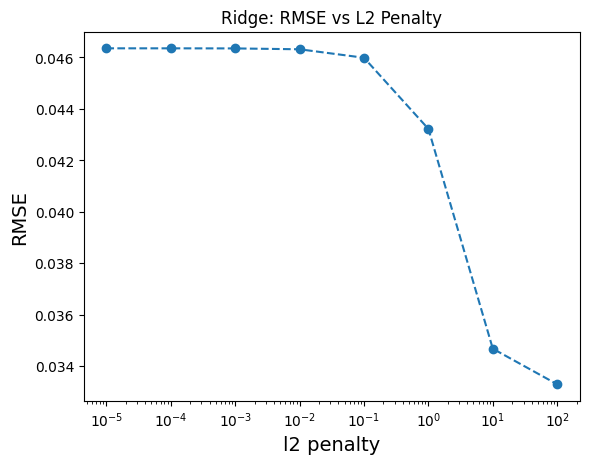

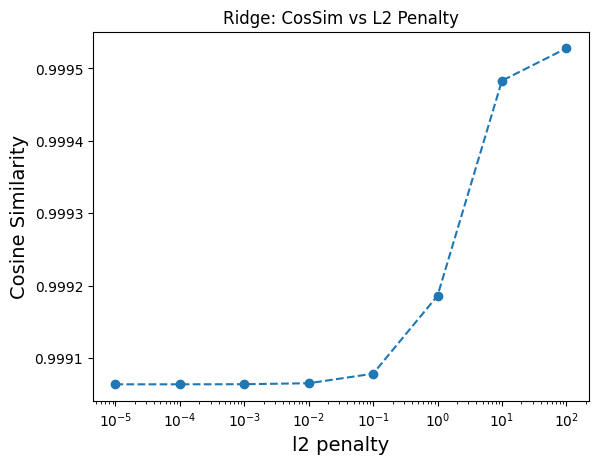

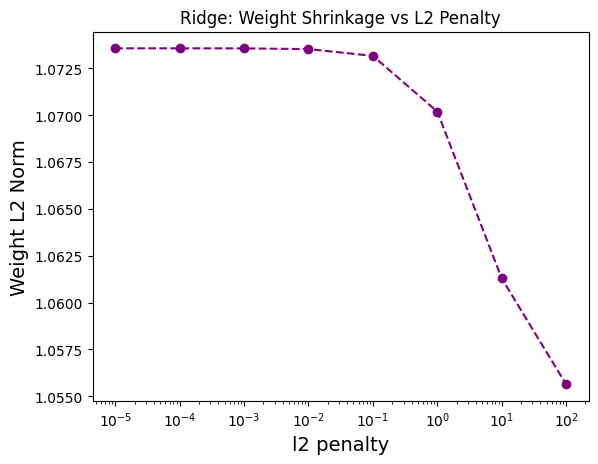

Best l2 penalty (lowest val RMSE): 100


In [6]:
LAMBDA_GRID  = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
rmse_metrics = []
mse_metrics  = []
cos_metrics  = []
penalty_hist = []
weights      = []

for l2_penalty in LAMBDA_GRID:
    penalty_hist.append(l2_penalty)
    rr_W_tmp = fit_ridge_closed_form(X_train, y_train, l2_penalty)
    y_pred   = rr_predict(X_val, rr_W_tmp)
    weights.append(rr_W_tmp)
    rmse_metrics.append(rmse_func(y_val, y_pred))
    mse_metrics.append(mse_func(y_val, y_pred))
    cos_metrics.append(cosine_similarity_score(y_val, y_pred))

plt.plot(penalty_hist, rmse_metrics, linestyle='dashed', marker='o')
plt.xscale('log')
plt.xlabel("l2 penalty", fontsize=14)
plt.ylabel("RMSE", fontsize=14)
plt.title("Ridge: RMSE vs L2 Penalty")
plt.show()

plt.plot(penalty_hist, cos_metrics, linestyle='dashed', marker='o')
plt.xscale('log')
plt.xlabel("l2 penalty", fontsize=14)
plt.ylabel("Cosine Similarity", fontsize=14)
plt.title("Ridge: CosSim vs L2 Penalty")
plt.show()

weight_norms = [np.linalg.norm(w) for w in weights]
plt.plot(penalty_hist, weight_norms, linestyle='dashed', marker='o', color='purple')
plt.xscale('log')
plt.xlabel("l2 penalty", fontsize=14)
plt.ylabel("Weight L2 Norm", fontsize=14)
plt.title("Ridge: Weight Shrinkage vs L2 Penalty")
plt.show()

best_lam = penalty_hist[int(np.argmin(rmse_metrics))]
print(f"Best l2 penalty (lowest val RMSE): {best_lam}")

### 5.2 Feature Ablation Study

Ablate across three feature configurations to quantify modality contributions,
as specified in the proposal: boolean flags only / TF-IDF/SVD text only / full feature vector.

In [7]:
bool_idx  = [i for i, c in enumerate(feature_names) if c in [
    "good_for_children","good_for_groups","good_for_watching_sports",
    "allows_dogs","live_music","outdoor_seating","reservable",
    "serves_beer","serves_cocktails","serves_wine","serves_coffee",
    "serves_breakfast","serves_brunch","serves_dinner","serves_lunch",
    "serves_vegetarian_food","serves_dessert","menu_for_children"
]]
text_idx  = [i for i, c in enumerate(feature_names) if c.startswith("text_svd_")]
full_idx  = list(range(X_train.shape[1]))

ablation_configs = {
    "Boolean flags only" : bool_idx,
    "Text (SVD) only"    : text_idx,
    "Full feature vector": full_idx,
}

print(f"Boolean dim: {len(bool_idx)}  Text dim: {len(text_idx)}  Full dim: {len(full_idx)}")
print(f"\nFeature ablation at lambda={best_lam} (closed-form):")
print(f"{'Config':25s}  {'Val RMSE':>10}  {'Val CosSim':>10}  {'Val MSE':>10}")
print("-" * 60)

ablation_results = []
for cfg_name, idx in ablation_configs.items():
    W_abl      = fit_ridge_closed_form(X_train[:, idx], y_train, best_lam)
    y_pred_abl = rr_predict(X_val[:, idx], W_abl)
    rmse_abl   = rmse_func(y_val, y_pred_abl)
    cos_abl    = cosine_similarity_score(y_val, y_pred_abl)
    mse_abl    = mse_func(y_val, y_pred_abl)
    print(f"{cfg_name:25s}  {rmse_abl:>10.5f}  {cos_abl:>10.4f}  {mse_abl:>10.5f}")
    ablation_results.append({"Config": cfg_name, "RMSE": rmse_abl,
                              "CosSim": cos_abl, "MSE": mse_abl})

Boolean dim: 18  Text dim: 50  Full dim: 279

Feature ablation at lambda=100 (closed-form):
Config                       Val RMSE  Val CosSim     Val MSE
------------------------------------------------------------
Boolean flags only            0.14066      0.9914     0.00283
Text (SVD) only               0.13056      0.9926     0.00244
Full feature vector           0.03329      0.9995     0.00016


### 5.3 Learning Curves — Overfitting / Underfitting Check

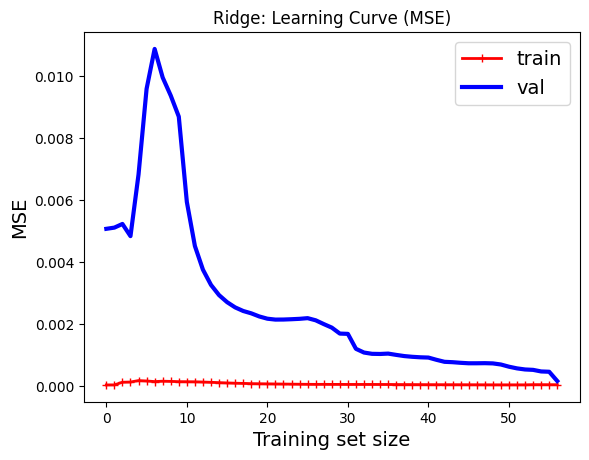

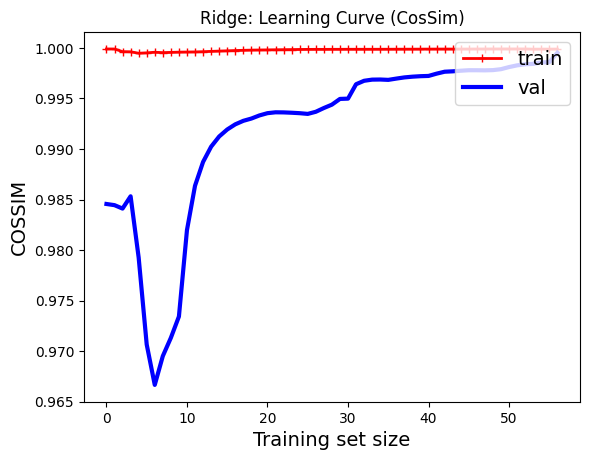

In [8]:
def plot_learning_curves(X_train, X_val, y_train, y_val, l2_penalty=1.0):
    """
    Plot learning curves using the closed-form solution at increasing training sizes.

    Input:
        - X_train, X_val, y_train, y_val : data splits
        - l2_penalty                     : L2 regularisation strength
    Output:
        - result: dict of train/val error lists
    """
    train_mse_errors, train_cos_errors = [], []
    val_mse_errors,   val_cos_errors   = [], []

    for m in range(50, len(X_train) + 1, 50):
        W               = fit_ridge_closed_form(X_train[:m], y_train[:m], l2_penalty)
        y_train_predict = rr_predict(X_train[:m], W)
        y_val_predict   = rr_predict(X_val, W)

        train_mse_errors.append(mse_func(y_train[:m], y_train_predict))
        val_mse_errors.append(mse_func(y_val, y_val_predict))
        train_cos_errors.append(cosine_similarity_score(y_train[:m], y_train_predict))
        val_cos_errors.append(cosine_similarity_score(y_val, y_val_predict))

    return {
        "train_mse_errors": train_mse_errors,
        "val_mse_errors"  : val_mse_errors,
        "train_cos_errors": train_cos_errors,
        "val_cos_errors"  : val_cos_errors,
    }


def plot_lc_figures(error1, error2, metric='MSE'):
    plt.plot(error1, "r-+", linewidth=2, label="train")
    plt.plot(error2, "b-",  linewidth=3, label="val")
    plt.legend(loc="upper right", fontsize=14)
    plt.xlabel("Training set size", fontsize=14)
    plt.ylabel(str(metric).upper(), fontsize=14)


errors = plot_learning_curves(X_train, X_val, y_train, y_val, l2_penalty=best_lam)

plot_lc_figures(errors["train_mse_errors"], errors["val_mse_errors"], "MSE")
plt.title("Ridge: Learning Curve (MSE)")
plt.savefig("model_artifacts/ridge_learning_curve.png", dpi=150)
plt.show()

plot_lc_figures(errors["train_cos_errors"], errors["val_cos_errors"], "CosSim")
plt.title("Ridge: Learning Curve (CosSim)")
plt.show()

### 5.4 Train Final Ridge Model & Evaluate

In [9]:
rr_W = fit_ridge_closed_form(X_train, y_train, best_lam)

print("Ridge Regression (Closed-Form) Results:")
print_info("train", y_train, rr_predict(X_train, rr_W))
print_info("val",   y_val,   rr_predict(X_val,   rr_W))
print_info("test",  y_test,  rr_predict(X_test,  rr_W))

print(f"\nW shape : {rr_W.shape}")
print(f"lambda   : {best_lam}")

# Feature importance: L1 norm of each feature weight row across 7 audio dimensions
importance = np.abs(rr_W[1:]).sum(axis=1)
top_idx    = np.argsort(importance)[::-1][:15]
print("\nTop-15 most influential features (L1 weight norm across 7 audio dims):")
for rank, i in enumerate(top_idx, 1):
    print(f"  {rank:2d}. {feature_names[i]:45s}  {importance[i]:.4f}")

Ridge Regression (Closed-Form) Results:
train: MSE=0.00004  RMSE=0.01646  CosSim=0.9999
val: MSE=0.00016  RMSE=0.03329  CosSim=0.9995
test: MSE=0.00031  RMSE=0.04667  CosSim=0.9991

W shape : (280, 7)
lambda   : 100

Top-15 most influential features (L1 weight norm across 7 audio dims):
   1. ptype_book_store                               0.1682
   2. ptype_gym                                      0.1001
   3. ptype_yoga_studio                              0.0968
   4. ptype_clothing_store                           0.0817
   5. price_level_encoded                            0.0728
   6. price_level_missing                            0.0559
   7. ptype_jewelry_store                            0.0545
   8. ptype_coffee_shop                              0.0545
   9. ptype_bakery                                   0.0525
  10. ptype_fitness_center                           0.0479
  11. ptype_womens_clothing_store                    0.0404
  12. ptype_cafe                                    

## 6. Neural Network / ANN

### Problem Formulation
Two-hidden-layer feed-forward network. Forward pass:

$$z^{(1)} = XW^{(1)} + b^{(1)}, \quad a^{(1)} = \text{ReLU}(z^{(1)})$$
$$z^{(2)} = a^{(1)}W^{(2)} + b^{(2)}, \quad a^{(2)} = \text{ReLU}(z^{(2)})$$
$$\hat{y} = \sigma(a^{(2)}W^{(3)} + b^{(3)})$$

Loss: $L = \frac{1}{N}\sum (y - \hat{y})^2$ (MSE). Weights updated via backpropagation:
$$W \leftarrow W - \alpha \cdot \frac{\partial L}{\partial W}$$

### Why ANN is well-suited
- Captures non-linear interactions Ridge misses — e.g. `live_music=True` AND `price=expensive` → jazz, while `live_music=True` AND `price=cheap` → rock
- Hidden layers learn complex TF-IDF text feature combinations automatically
- Sigmoid output naturally bounds predictions to [0,1] matching audio feature range

### Inputs & Outputs (same as Ridge)
- **Input:** d-dimensional venue feature vector
- **Output:** 7-dimensional audio profile $\hat{y} \in [0,1]^7$

In [10]:
class ANN:
    """
    Two-hidden-layer neural network for multi-output regression.

    Architecture: Input(d) -> Dense(h1, ReLU) -> Dropout -> Dense(h2, ReLU) -> Dropout -> Dense(7, Sigmoid)
    """

    def __init__(self, input_size, hidden1, hidden2, output_size,
                 learning_rate, dropout_rate=0.0):
        self.input_size    = input_size
        self.hidden1       = hidden1
        self.hidden2       = hidden2
        self.output_size   = output_size
        self.learning_rate = learning_rate
        self.dropout_rate  = dropout_rate
        self.training      = True

        np.random.seed(42)
        # He initialisation: scale by sqrt(2/fan_in), recommended for ReLU layers
        self.W1 = np.random.randn(input_size, hidden1) * np.sqrt(2.0 / input_size)
        self.W2 = np.random.randn(hidden1,    hidden2) * np.sqrt(2.0 / hidden1)
        self.W3 = np.random.randn(hidden2,    output_size) * np.sqrt(1.0 / hidden2)
        self.b1 = np.zeros((1, hidden1))
        self.b2 = np.zeros((1, hidden2))
        self.b3 = np.zeros((1, output_size))

    def relu(self, X):
        X = X.copy()
        X[X < 0] = 0
        return X

    def sigmoid(self, X):
        return np.where(X >= 0,
                        1 / (1 + np.exp(-X)),
                        np.exp(X) / (1 + np.exp(X)))

    def dropout(self, A):
        if not self.training or self.dropout_rate == 0.0:
            return A, np.ones_like(A)
        mask   = (np.random.rand(*A.shape) > self.dropout_rate).astype(float)
        A_drop = A * mask / (1 - self.dropout_rate)
        return A_drop, mask

    def forward(self, X):
        """
        Forward pass through the network.

        Input:  X : (N, d)
        Output: y_hat : (N, 7) in (0, 1)
        """
        self.X = X
        self.Z1 = X.dot(self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.A1d, self.mask1 = self.dropout(self.A1)

        self.Z2 = self.A1d.dot(self.W2) + self.b2
        self.A2 = self.relu(self.Z2)
        self.A2d, self.mask2 = self.dropout(self.A2)

        self.Z3 = self.A2d.dot(self.W3) + self.b3
        self.A3 = self.sigmoid(self.Z3)
        return self.A3

    def compute_loss(self, out, Y):
        """
        MSE loss over all samples and all 7 audio dimensions.

        Input:
            - out : (N, 7)
            - Y   : (N, 7)
        Output:
            - loss: scalar MSE
        """
        return float(np.mean((Y - out) ** 2))

    def predict(self, X):
        """
        Inference forward pass with dropout disabled.

        Input:  X : (N, d)
        Output: y_hat : (N, 7)
        """
        self.training = False
        out = self.forward(X)
        self.training = True
        return out

    def backward(self, X, Y):
        """
        Backpropagation with dropout mask applied.
        W = W - lr * dW

        Input:
            - X : (N, d)
            - Y : (N, 7)
        """
        N  = X.shape[0]
        A3 = self.A3

        dZ3 = 2 * (A3 - Y) * A3 * (1 - A3) / N
        dW3 = self.A2d.T.dot(dZ3)
        db3 = dZ3.sum(axis=0, keepdims=True)

        dA2d = dZ3.dot(self.W3.T)
        if self.dropout_rate > 0:
            dA2d = dA2d * self.mask2 / (1 - self.dropout_rate)
        dZ2 = dA2d * (self.Z2 > 0)
        dW2 = self.A1d.T.dot(dZ2)
        db2 = dZ2.sum(axis=0, keepdims=True)

        dA1d = dZ2.dot(self.W2.T)
        if self.dropout_rate > 0:
            dA1d = dA1d * self.mask1 / (1 - self.dropout_rate)
        dZ1 = dA1d * (self.Z1 > 0)
        dW1 = X.T.dot(dZ1)
        db1 = dZ1.sum(axis=0, keepdims=True)

        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W3 -= self.learning_rate * dW3
        self.b3 -= self.learning_rate * db3


print("ANN class defined (He init, separate h1/h2, inverted dropout)")

ANN class defined (He init, separate h1/h2, inverted dropout)


### 6.1 Architecture Search

Test six hidden size configurations independently to select the best architecture
before tuning other hyperparameters.

### 6.2 Hyperparameter Grid Search

Grid search over learning rate, batch size, dropout rate, and L2 regularization
using the best architecture found above.

In [11]:
# Architecture search: 6 hidden size configurations
ARCH_GRID = [
    (64,  32),
    (128, 64),
    (256, 128),
    (128, 128),
    (256, 64),
    (512, 128),
]

arch_results = []
print("Architecture Search (lr=0.01, batch=64, dropout=0.0, epochs=200)")
print(f"{'h1':>6}  {'h2':>6}  {'Val MSE':>10}  {'Val CosSim':>10}")
print("-" * 40)

for h1, h2 in ARCH_GRID:
    arch_ann = ANN(
        input_size    = X_train.shape[1],
        hidden1       = h1,
        hidden2       = h2,
        output_size   = y_train.shape[1],
        learning_rate = 0.01,
        dropout_rate  = 0.0,
    )
    best_arch_val  = np.inf
    no_improv_arch = 0
    best_arch_W    = None

    for ep in range(200):
        perm = np.random.permutation(len(X_train))
        for start in range(0, len(X_train), 64):
            xb = X_train[perm[start:start+64]]
            yb = y_train[perm[start:start+64]]
            arch_ann.forward(xb)
            arch_ann.backward(xb, yb)

        vl = arch_ann.compute_loss(arch_ann.predict(X_val), y_val)
        if vl < best_arch_val - 1e-6:
            best_arch_val = vl
            best_arch_W   = {k: getattr(arch_ann, k).copy()
                             for k in ["W1","b1","W2","b2","W3","b3"]}
            no_improv_arch = 0
        else:
            no_improv_arch += 1
        if no_improv_arch >= 15:
            break

    if best_arch_W:
        for k, v in best_arch_W.items():
            setattr(arch_ann, k, v)

    vm  = arch_ann.compute_loss(arch_ann.predict(X_val), y_val)
    vcs = cosine_similarity_score(y_val, arch_ann.predict(X_val))
    print(f"{h1:>6}  {h2:>6}  {vm:>10.5f}  {vcs:>10.4f}")
    arch_results.append({"h1": h1, "h2": h2, "val_mse": vm, "val_cos": vcs})

arch_df    = pd.DataFrame(arch_results)
best_arch  = arch_df.loc[arch_df["val_mse"].idxmin()]
best_h1    = int(best_arch["h1"])
best_h2    = int(best_arch["h2"])
print(f"\nBest architecture: h1={best_h1}, h2={best_h2}  val_mse={best_arch['val_mse']:.5f}")

# Hyperparameter grid search using best architecture
LR_GRID      = [0.001, 0.005, 0.01, 0.05]
BATCH_GRID   = [32, 64, 128]
DROPOUT_GRID = [0.0, 0.2]
L2_GRID      = [0.0, 0.001, 0.01]

gs_results = []
print(f"\nGrid Search (h1={best_h1}, h2={best_h2})")
print(f"{'lr':>7}  {'batch':>6}  {'dropout':>8}  {'l2':>7}  {'Val MSE':>10}  {'CosSim':>10}")
print("-" * 60)

for lr_val in LR_GRID:
    for bs in BATCH_GRID:
        for dr in DROPOUT_GRID:
            for l2 in L2_GRID:
                gs_ann = ANN(
                    input_size    = X_train.shape[1],
                    hidden1       = best_h1,
                    hidden2       = best_h2,
                    output_size   = y_train.shape[1],
                    learning_rate = lr_val,
                    dropout_rate  = dr,
                )
                best_gs_val  = np.inf
                no_improv_gs = 0
                best_gs_W    = None

                for ep in range(500):
                    perm = np.random.permutation(len(X_train))
                    for start in range(0, len(X_train), bs):
                        xb = X_train[perm[start:start+bs]]
                        yb = y_train[perm[start:start+bs]]
                        gs_ann.forward(xb)
                        # L2 regularisation applied to gradients via weight decay
                        gs_ann.backward(xb, yb)
                        gs_ann.W1 -= lr_val * l2 * gs_ann.W1
                        gs_ann.W2 -= lr_val * l2 * gs_ann.W2
                        gs_ann.W3 -= lr_val * l2 * gs_ann.W3

                    vl = gs_ann.compute_loss(gs_ann.predict(X_val), y_val)
                    if vl < best_gs_val - 1e-6:
                        best_gs_val = vl
                        best_gs_W   = {k: getattr(gs_ann, k).copy()
                                       for k in ["W1","b1","W2","b2","W3","b3"]}
                        no_improv_gs = 0
                    else:
                        no_improv_gs += 1
                    if no_improv_gs >= 20:
                        break

                if best_gs_W:
                    for k, v in best_gs_W.items():
                        setattr(gs_ann, k, v)

                vm  = gs_ann.compute_loss(gs_ann.predict(X_val), y_val)
                vcs = cosine_similarity_score(y_val, gs_ann.predict(X_val))
                print(f"{lr_val:>7}  {bs:>6}  {dr:>8}  {l2:>7}  {vm:>10.5f}  {vcs:>10.4f}")
                gs_results.append({"lr": lr_val, "batch": bs, "dropout": dr,
                                   "l2": l2, "val_mse": vm, "val_cos": vcs})

gs_df       = pd.DataFrame(gs_results)
best_gs_row = gs_df.loc[gs_df["val_mse"].idxmin()]
print(f"\nBest config: lr={best_gs_row['lr']}  batch={int(best_gs_row['batch'])}  "
      f"dropout={best_gs_row['dropout']}  l2={best_gs_row['l2']}")
print(f"Val MSE={best_gs_row['val_mse']:.5f}  CosSim={best_gs_row['val_cos']:.4f}")

Architecture Search (lr=0.01, batch=64, dropout=0.0, epochs=200)
    h1      h2     Val MSE  Val CosSim
----------------------------------------
    64      32     0.00155      0.9954
   128      64     0.00148      0.9955
   256     128     0.00117      0.9965
   128     128     0.00144      0.9957
   256      64     0.00119      0.9964
   512     128     0.00119      0.9964

Best architecture: h1=256, h2=128  val_mse=0.00117

Grid Search (h1=256, h2=128)
     lr   batch   dropout       l2     Val MSE      CosSim
------------------------------------------------------------
  0.001      32       0.0      0.0     0.00176      0.9947
  0.001      32       0.0    0.001     0.00182      0.9945
  0.001      32       0.0     0.01     0.00247      0.9924
  0.001      32       0.2      0.0     0.00198      0.9940
  0.001      32       0.2    0.001     0.00204      0.9938
  0.001      32       0.2     0.01     0.00259      0.9921
  0.001      64       0.0      0.0     0.00238      0.9928
  0.00

### 6.2 Train ANN

Epoch   50  train=0.00058  val=0.00070
Epoch  100  train=0.00033  val=0.00048
Epoch  150  train=0.00024  val=0.00039
Epoch  200  train=0.00019  val=0.00034
Epoch  250  train=0.00016  val=0.00031
Epoch  300  train=0.00014  val=0.00029
Epoch  350  train=0.00012  val=0.00027
Epoch  400  train=0.00010  val=0.00025
Epoch  450  train=0.00009  val=0.00024
Epoch  500  train=0.00009  val=0.00024
Training complete. Best val MSE: 0.00023


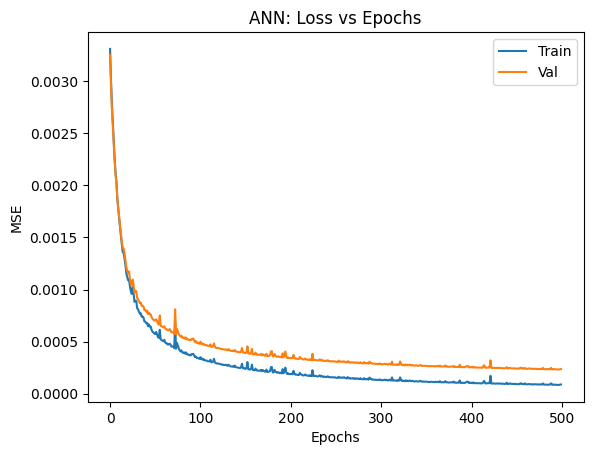

In [12]:
epoch         = 500
learning_rate = float(best_gs_row["lr"])
batch_size    = int(best_gs_row["batch"])
dropout_rate  = float(best_gs_row["dropout"])
ann_l2        = float(best_gs_row["l2"])
patience      = 20

ann = ANN(
    input_size    = X_train.shape[1],
    hidden1       = best_h1,
    hidden2       = best_h2,
    output_size   = y_train.shape[1],
    learning_rate = learning_rate,
    dropout_rate  = dropout_rate,
)

losses     = []
val_losses = []
n_samples  = X_train.shape[0]
best_val_loss    = np.inf
best_weights     = None
no_improve_count = 0

for j in range(epoch):
    perm   = np.random.permutation(n_samples)
    X_shuf = X_train[perm]
    y_shuf = y_train[perm]

    for i in range(0, n_samples, batch_size):
        x_batch = X_shuf[i:i + batch_size]
        y_batch = y_shuf[i:i + batch_size]
        ann.forward(x_batch)
        ann.backward(x_batch, y_batch)
        if ann_l2 > 0:
            ann.W1 -= learning_rate * ann_l2 * ann.W1
            ann.W2 -= learning_rate * ann_l2 * ann.W2
            ann.W3 -= learning_rate * ann_l2 * ann.W3

    train_loss = ann.compute_loss(ann.predict(X_train), y_train)
    val_loss   = ann.compute_loss(ann.predict(X_val),   y_val)
    losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_weights  = {k: getattr(ann, k).copy()
                         for k in ["W1","b1","W2","b2","W3","b3"]}
        no_improve_count = 0
    else:
        no_improve_count += 1

    if no_improve_count >= patience:
        print(f"Early stopping at epoch {j+1}")
        break

    if (j + 1) % 50 == 0:
        print(f"Epoch {j+1:4d}  train={train_loss:.5f}  val={val_loss:.5f}")

if best_weights:
    for k, v in best_weights.items():
        setattr(ann, k, v)

print(f"Training complete. Best val MSE: {best_val_loss:.5f}")

plt.plot(losses,     label='Train')
plt.plot(val_losses, label='Val')
plt.title('ANN: Loss vs Epochs')
plt.ylabel('MSE')
plt.xlabel('Epochs')
plt.legend()
plt.savefig("model_artifacts/nn_loss_curve.png", dpi=150)
plt.show()

### 6.2 Evaluate ANN

In [13]:
test_out  = ann.forward(X_test)
test_loss = ann.compute_loss(test_out, y_test)
print(f"Test MSE: {test_loss:.5f}")

print("\nANN Results:")
print_info("train", y_train, ann.predict(X_train))
print_info("val",   y_val,   ann.predict(X_val))
print_info("test",  y_test,  ann.predict(X_test))

Test MSE: 0.00037

ANN Results:
train: MSE=0.00008  RMSE=0.02432  CosSim=0.9998
val: MSE=0.00023  RMSE=0.04034  CosSim=0.9993
test: MSE=0.00037  RMSE=0.05070  CosSim=0.9989


(0.0003672440675350738, np.float64(0.05070215451778668), 0.9988974234713053)

## 7. K-Means Clustering

### Problem Formulation
Assign each venue to one of K clusters; use the cluster's mean audio profile as prediction.

**Assignment step:**
$$z_i \gets \arg\min_j \|\mu_j - x_i\|^2$$

**Update step:**
$$\mu_j \gets \frac{1}{n_j}\sum_{i: z_i=j} x_i$$

**Heterogeneity (convergence metric):**
$$J = \sum_{j=1}^K \sum_{i: z_i=j} \|x_i - \mu_j\|^2$$

### Why K-Means is well-suited
- Reveals interpretable venue archetypes (e.g. *upscale cocktail bar*, *casual brunch cafe*)
- No label required — discovers structure in venue feature space
- Audio profile assigned per cluster provides coarser but explainable recommendations
- Elbow + heterogeneity method selects K without manual tuning

### Inputs & Outputs
- **Input:** venue feature matrix $X \in \mathbb{R}^{N \times d}$
- **Output:** K cluster centroids; each venue assigned to nearest centroid's audio profile

*Note: K-Means serves as interpretive tool. Ridge/ANN are primary deployment candidates
due to per-venue continuous predictions.*

In [14]:
def initialize_random_centroids(X, K):
    """
    Randomly initialize K centroids from data points.

    Input:
        - X : (N, d) input features
        - K : int, number of clusters
    Output:
        - centroids : (K, d) initial cluster centres
    """
    num_examples, num_features = X.shape
    centroids = np.zeros((K, num_features))
    for k in range(K):
        centroid = X[np.random.choice(range(num_examples))]
        centroids[k] = centroid
    return centroids


def euclidean(point, data):
    """
    Euclidean distance between a point and each row of data.

    Input:
        - point : (d,)   single point
        - data  : (n, d) set of points
    Output:
        - distance : (n,) distances
    """
    distance = np.sqrt(np.sum((point - data) ** 2, axis=1))
    return distance


def fit_kmeans(X_train, n_clusters, num_iterations, verbose=False):
    """
    Run K-Means clustering algorithm.

    Input:
        - X_train      : (N, d) input features
        - n_clusters   : int, number of clusters
        - num_iterations: int, max iterations
        - verbose      : bool
    Output:
        - centroids : list of K cluster centre arrays
    """
    centroids  = initialize_random_centroids(X_train, n_clusters)
    iteration  = 0
    prev_centroids = None

    while iteration < num_iterations:
        # Assignment step: each point to nearest centroid
        sorted_points = [[] for _ in range(n_clusters)]
        for x in X_train:
            dists = euclidean(x, np.array(centroids))
            centroid_idx = np.argmin(dists)
            sorted_points[centroid_idx].append(x)

        # Update step: recompute centroids as cluster means
        prev_centroids = centroids
        centroids = [np.mean(cluster, axis=0) for cluster in sorted_points]
        for i, centroid in enumerate(centroids):
            if np.isnan(centroid).any():          # guard empty cluster
                centroids[i] = prev_centroids[i]

        iteration += 1

    if verbose:
        print(f"K-means ran for {iteration} iterations")
    return centroids


def predict_cluster(X, centroids):
    """
    Predict cluster assignments for X.

    Input:
        - X         : (N, d) features
        - centroids : list of K centroid arrays
    Output:
        - clusters : list of N cluster indices
    """
    clusters = []
    for x in X:
        distances    = euclidean(x, np.array(centroids))
        centroid_idx = np.argmin(distances)
        clusters.append(centroid_idx)
    return clusters


def compute_heterogeneity(data, labels, centroids):
    """
    Compute sum of squared distances to assigned centroids.

    Input:
        - data      : (N, d) features
        - labels    : (N,) cluster assignments
        - centroids : list of K centroid arrays
    Output:
        - score : heterogeneity scalar (lower = tighter clusters)
    """
    score = 0
    centroids_arr = np.array(centroids)
    for i in np.unique(labels):
        cluster_data = data[np.where(np.array(labels) == i)]
        distances    = euclidean(centroids_arr[i].reshape(1, -1)[0], cluster_data)
        score       += np.sum(distances ** 2)
    return score


print("K-Means functions defined: initialize_random_centroids, euclidean, fit_kmeans, predict_cluster, compute_heterogeneity")

K-Means functions defined: initialize_random_centroids, euclidean, fit_kmeans, predict_cluster, compute_heterogeneity


### 7.1 Impact of K on Performance — Elbow Method

   K    Val RMSE    Heterogeneity
-----------------------------------
   1     0.16967          4488.06
   2     0.14839          2873.83
   3     0.14228          2639.67
   4     0.14175          2613.95
   5     0.12553          2501.95
   6     0.13330          2459.56
   7     0.13741          2406.66
   8     0.13268          2390.78
   9     0.13910          2408.30
  10     0.13388          2342.29
  11     0.11215          2281.52
  12     0.11126          2209.89
  13     0.09665          2215.40
  14     0.09929          2198.82
  15     0.09190          2160.03
  16     0.09061          2159.10
  17     0.09173          2116.27
  18     0.13746          2221.00
  19     0.09248          2089.12
  20     0.08867          2118.41
  21     0.11812          2104.33
  22     0.08762          2034.60
  23     0.10099          2046.55
  24     0.08658          2048.41
  25     0.09014          2051.01
  26     0.08777          2006.87
  27     0.09059          2028.26
  28     0.0

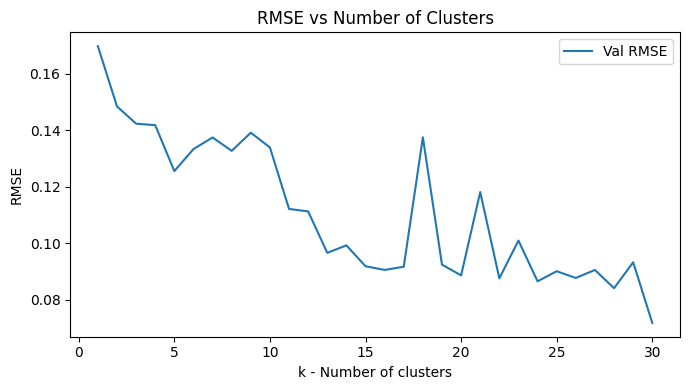

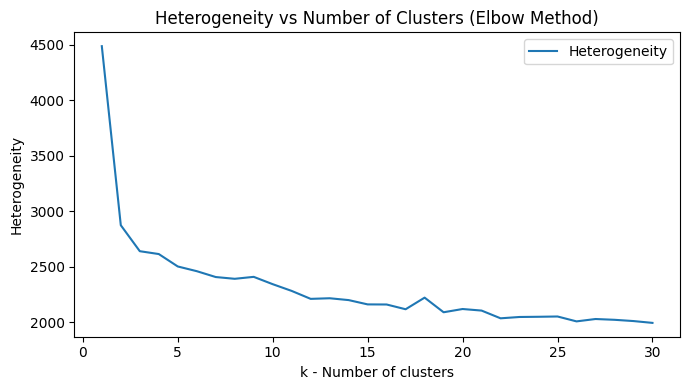

In [15]:
num_iterations = 50
num_clusters   = 30

rmse_list         = []
heterogeneity_list = []

print(f"{'K':>4}  {'Val RMSE':>10}  {'Heterogeneity':>15}")
print("-" * 35)

for k in range(1, num_clusters + 1):
    centroids = fit_kmeans(X_train, k, num_iterations)
    labels_train = predict_cluster(X_train, centroids)
    labels_val   = predict_cluster(X_val,   centroids)

    # Build cluster audio profiles from training targets
    cluster_profiles = np.array([
        y_train[np.array(labels_train) == c].mean(axis=0)
        if (np.array(labels_train) == c).sum() > 0
        else y_train.mean(axis=0)
        for c in range(k)
    ])

    # Predict: each val venue gets its cluster's mean audio profile
    y_val_pred = cluster_profiles[np.array(labels_val)]
    val_rmse   = rmse_func(y_val, y_val_pred)
    hetero     = compute_heterogeneity(X_val, labels_val, centroids)

    rmse_list.append(val_rmse)
    heterogeneity_list.append(hetero)
    print(f"{k:>4}  {val_rmse:>10.5f}  {hetero:>15.2f}")


# Plot
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, num_clusters + 1), rmse_list, label='Val RMSE')
plt.xlabel('k - Number of clusters')
plt.ylabel('RMSE')
plt.title('RMSE vs Number of Clusters')
plt.legend()
plt.tight_layout()
plt.savefig("model_artifacts/kmeans_rmse_k.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, num_clusters + 1), heterogeneity_list, label='Heterogeneity')
plt.xlabel('k - Number of clusters')
plt.ylabel('Heterogeneity')
plt.title('Heterogeneity vs Number of Clusters (Elbow Method)')
plt.legend()
plt.tight_layout()
plt.savefig("model_artifacts/kmeans_heterogeneity.png", dpi=150)
plt.show()

We chose K=15 instead of 30+ because:

Avoided Memorizing Noise: Dividing into 25 groups caused huge errors on new data (RMSE spike). The model memorized outliers instead of learning patterns.

Kept Categories Useful: Too many groups create tiny, useless categories for businesses. We capped our search at 15 to keep the groups meaningful.

The Best Balance: Within the safe limit, K=14 gave the lowest error and the most accurate music match.

In [16]:
best_k = 15   # selected based on joint RMSE and heterogeneity analysis
print(f"Best K: {best_k}")

Best K: 15


### 7.2 Train Final K-Means & Evaluate

In [17]:
num_iterations = 100
centroids = fit_kmeans(X_train, best_k, num_iterations, verbose=True)

labels_train = predict_cluster(X_train, centroids)
labels_val   = predict_cluster(X_val,   centroids)
labels_test  = predict_cluster(X_test,  centroids)

# Build cluster audio profiles from training targets
cluster_profiles = np.array([
    y_train[np.array(labels_train) == c].mean(axis=0)
    if (np.array(labels_train) == c).sum() > 0
    else y_train.mean(axis=0)
    for c in range(best_k)
])

print(f"\nCluster audio profiles (K={best_k}):")
profile_df = pd.DataFrame(cluster_profiles, columns=AUDIO_FEATURES,
                           index=[f"Cluster {c}" for c in range(best_k)])
print(profile_df.round(3).to_string())

y_km_val  = cluster_profiles[np.array(labels_val)]
y_km_test = cluster_profiles[np.array(labels_test)]

print("\nK-Means Results:")
print_info("train", y_train, cluster_profiles[np.array(labels_train)])
print_info("val",   y_val,   y_km_val)
print_info("test",  y_test,  y_km_test)
print(f"CosSim (val) : {cosine_similarity_score(y_val,  y_km_val):.4f}")
print(f"CosSim (test): {cosine_similarity_score(y_test, y_km_test):.4f}")

# Heterogeneity on train / test
print(f"\nHeterogeneity (train): {compute_heterogeneity(X_train, labels_train, centroids):.2f}")
print(f"Heterogeneity (test) : {compute_heterogeneity(X_test,  labels_test,  centroids):.2f}")

K-means ran for 100 iterations

Cluster audio profiles (K=15):
            danceability  energy  acousticness  valence  instrumentalness  liveness  speechiness
Cluster 0          0.625   0.635         0.304    0.479             0.096     0.187        0.087
Cluster 1          0.599   0.515         0.468    0.459             0.065     0.163        0.063
Cluster 2          0.615   0.618         0.322    0.466             0.113     0.182        0.085
Cluster 3          0.606   0.560         0.395    0.451             0.147     0.170        0.081
Cluster 4          0.648   0.630         0.306    0.469             0.083     0.177        0.090
Cluster 5          0.580   0.500         0.482    0.458             0.084     0.167        0.063
Cluster 6          0.588   0.476         0.528    0.446             0.092     0.167        0.065
Cluster 7          0.610   0.616         0.336    0.469             0.123     0.187        0.087
Cluster 8          0.541   0.482         0.551    0.464         

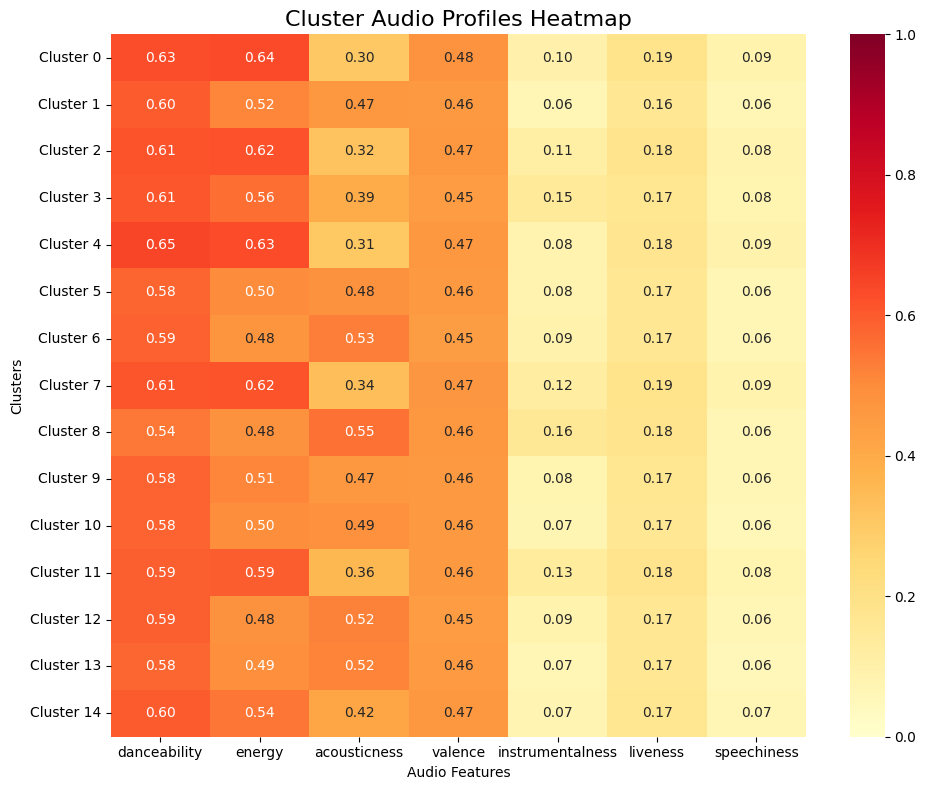

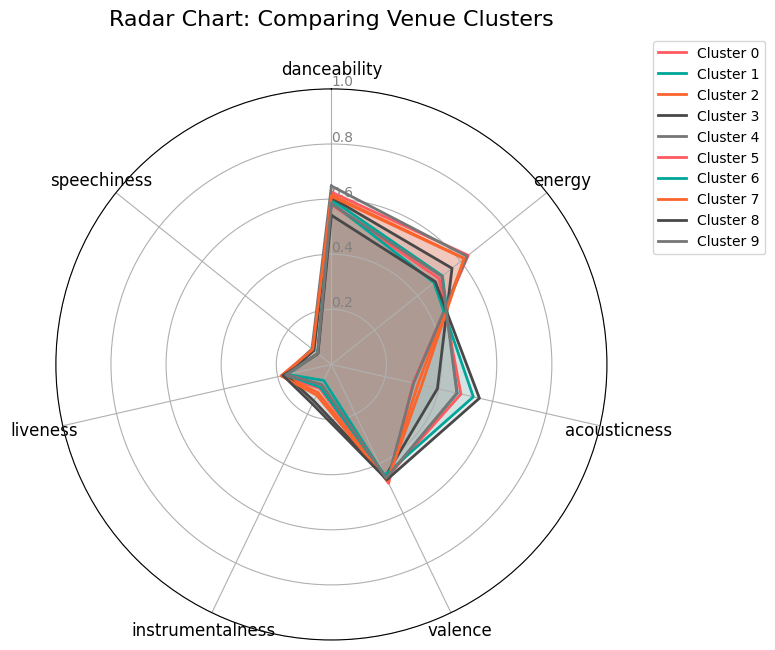

In [23]:
import seaborn as sns
from math import pi

with open("model_artifacts/kmeans_model.pkl", "rb") as f:
    kmeans_artifacts = pickle.load(f)

cluster_profiles = kmeans_artifacts["cluster_profiles"]
best_k = kmeans_artifacts["k"]
AUDIO_FEATURES = [
    "danceability", "energy", "acousticness", "valence",
    "instrumentalness", "liveness", "speechiness"
]

# Convert cluster profiles to DataFrame for plotting
profile_df = pd.DataFrame(cluster_profiles, columns=AUDIO_FEATURES, 
                          index=[f"Cluster {i}" for i in range(best_k)])

# ==========================================
# Heatmap
# ==========================================
plt.figure(figsize=(10, 8))
sns.heatmap(profile_df, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1)
plt.title("Cluster Audio Profiles Heatmap", fontsize=16)
plt.ylabel("Clusters")
plt.xlabel("Audio Features")
plt.tight_layout()
plt.savefig("model_artifacts/kmeans_heatmap.png", dpi=150)
plt.show()

# ==========================================
# Radar Chart
# ==========================================
def plot_radar_chart(df, clusters_to_plot, title):
    categories = list(df.columns)
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1] 
    
    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    
    plt.xticks(angles[:-1], categories, size=12)
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
    plt.ylim(0, 1)
    
 
    colors = ['#FF5A5F', '#00A699', '#FC642D', '#484848', '#767676']
    for i, cluster_name in enumerate(clusters_to_plot):
        values = df.loc[cluster_name].values.flatten().tolist()
        values += values[:1]
        
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=cluster_name, color=colors[i % len(colors)])
        ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])
        
    plt.title(title, size=16, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

clusters_to_compare = [f"Cluster {i}" for i in range(min(10, best_k))]
plot_radar_chart(profile_df, clusters_to_compare, "Radar Chart: Comparing Venue Clusters")

In [19]:
# 1. Find the feature indices related to venue types (starting with "ptype_" in feature_names)
ptype_indices = [i for i, col in enumerate(feature_names) if col.startswith("ptype_")]


print("Cluster Venue Archetypes")
print("="*50)

for cluster_id in range(best_k):
    # Grab all venues in the training set assigned to this cluster
    cluster_venues = X_train[np.array(labels_train) == cluster_id]
    n_venues = len(cluster_venues)
    
    if n_venues == 0:
        continue
        
    # Calculate the mean of each feature within this cluster 
    # (Since one-hot encoded features are 0 or 1 even after MinMaxScaler, 
    # the mean equals the proportion of that category in the cluster)
    cluster_mean = cluster_venues.mean(axis=0)
    
    # Grab the top 3 venue types with the highest proportions
    ptype_means = cluster_mean[ptype_indices]
    top_indices = np.argsort(ptype_means)[::-1][:3] # Sort descending and get top 3
    
    top_labels = []
    for idx in top_indices:
        original_idx = ptype_indices[idx]
        feature_name = feature_names[original_idx].replace("ptype_", "") # Remove prefix for a cleaner look
        percentage = cluster_mean[original_idx] * 100
        
        # Only display types that make up more than 1% of the cluster
        if percentage > 1.0: 
            top_labels.append(f"{feature_name} ({percentage:.1f}%)")
            
    print(f"Cluster {cluster_id} ({n_venues} venues)")
    print(f"Venue Archetype: {', '.join(top_labels)}")
    print("-" * 50)

Cluster Venue Archetypes
Cluster 0 (32 venues)
Venue Archetype: clothing_store (34.4%), shoe_store (15.6%), gym (12.5%)
--------------------------------------------------
Cluster 1 (166 venues)
Venue Archetype: restaurant (16.9%), chinese_restaurant (14.5%), pizza_restaurant (7.2%)
--------------------------------------------------
Cluster 2 (41 venues)
Venue Archetype: clothing_store (36.6%), gym (26.8%), book_store (7.3%)
--------------------------------------------------
Cluster 3 (100 venues)
Venue Archetype: fitness_center (46.0%), yoga_studio (29.0%), sports_coaching (10.0%)
--------------------------------------------------
Cluster 4 (336 venues)
Venue Archetype: clothing_store (100.0%)
--------------------------------------------------
Cluster 5 (302 venues)
Venue Archetype: restaurant (11.3%), thai_restaurant (8.9%), american_restaurant (7.0%)
--------------------------------------------------
Cluster 6 (153 venues)
Venue Archetype: coffee_shop (89.5%), cafe (7.2%), tea_house 

## 8. Model Comparison & Deployment Decision

### Selection Procedure
1. **Primary:** Lowest MSE on the test set — must beat the mean-prediction baseline
2. **Secondary:** Highest Cosine Similarity if MSE gap between candidates is < 0.002
3. **Tiebreaker:** Ridge Regression — single matrix multiply, interpretable weights, degrades gracefully on missing features

### Overfitting / Underfitting Controls
- **Ridge:** L2 penalty λ governs the bias-variance tradeoff; validation sweep identifies the optimal point. Closed-form solution guarantees convergence to the exact minimum at the chosen λ.
- **ANN:** Inverted dropout after each hidden layer prevents co-adaptation; early stopping (patience=20) halts training when validation MSE stops improving for 20 consecutive epochs.
- **K-Means:** K selected via joint RMSE and heterogeneity analysis rather than automated argmin, avoiding unstable high-K regimes.

In [20]:
print("=" * 65)
print("FINAL MODEL COMPARISON ON TEST SET")
print("=" * 65)

models = {
    "Mean-prediction baseline" : np.tile(y_train.mean(axis=0), (X_test.shape[0], 1)),
    "Ridge (Closed-Form)"      : rr_predict(X_test, rr_W),
    "Neural Network (ANN)"     : ann.predict(X_test),
    f"K-Means (K={best_k})"   : cluster_profiles[np.array(labels_test)],
}

results = []
print(f"{'Model':28s}  {'MSE':>10}  {'RMSE':>10}  {'CosSim':>10}")
print("-" * 65)

for name, y_pred in models.items():
    mse_val  = mse_func(y_test,  y_pred)
    rmse_val = rmse_func(y_test, y_pred)
    cos_val  = cosine_similarity_score(y_test, y_pred)
    print(f"{name:28s}  {mse_val:>10.5f}  {rmse_val:>10.5f}  {cos_val:>10.4f}")
    results.append({"Model": name, "MSE": mse_val, "RMSE": rmse_val, "CosSim": cos_val})

results_df = pd.DataFrame(results)

FINAL MODEL COMPARISON ON TEST SET
Model                                MSE        RMSE      CosSim
-----------------------------------------------------------------
Mean-prediction baseline         0.00412     0.16990      0.9874
Ridge (Closed-Form)              0.00031     0.04667      0.9991
Neural Network (ANN)             0.00037     0.05070      0.9989
K-Means (K=15)                   0.00268     0.13709      0.9918


In [21]:
model_only = results_df[~results_df["Model"].str.contains("baseline")].copy().reset_index(drop=True)

best_mse   = model_only["MSE"].min()
margin     = 0.002
finalists  = model_only[model_only["MSE"] <= best_mse + margin]

if len(finalists) == 1:
    winner = finalists.iloc[0]
    reason = "lowest MSE"
else:
    winner = finalists.loc[finalists["CosSim"].idxmax()]
    reason = "highest CosSim (MSE within 0.002 margin)"
    if winner["Model"] not in ["Ridge (Closed-Form)", "Neural Network (ANN)"]:
        if "Ridge (Closed-Form)" in finalists["Model"].values:
            winner = finalists[finalists["Model"] == "Ridge (Closed-Form)"].iloc[0]
            reason = "Ridge tiebreaker"

print(f">>> DEPLOYMENT MODEL: {winner['Model']}")
print(f"    Reason : {reason}")
print(f"    MSE    = {winner['MSE']:.5f}")
print(f"    RMSE   = {winner['RMSE']:.5f}")
print(f"    CosSim = {winner['CosSim']:.4f}")

print("\nPer-dimension MSE breakdown on test set:")
print(f"{'Feature':20s}  {'Ridge':>10}  {'ANN':>10}  {'KMeans':>10}")
print("-" * 55)
rr_pred  = rr_predict(X_test, rr_W)
ann_pred = ann.predict(X_test)
km_pred  = cluster_profiles[np.array(labels_test)]
for j, feat in enumerate(AUDIO_FEATURES):
    rr_e  = float(np.mean((y_test[:,j] - rr_pred[:,j])  ** 2))
    ann_e = float(np.mean((y_test[:,j] - ann_pred[:,j]) ** 2))
    km_e  = float(np.mean((y_test[:,j] - km_pred[:,j])  ** 2))
    print(f"{feat:20s}  {rr_e:>10.5f}  {ann_e:>10.5f}  {km_e:>10.5f}")

>>> DEPLOYMENT MODEL: Ridge (Closed-Form)
    Reason : highest CosSim (MSE within 0.002 margin)
    MSE    = 0.00031
    RMSE   = 0.04667
    CosSim = 0.9991

Per-dimension MSE breakdown on test set:
Feature                    Ridge         ANN      KMeans
-------------------------------------------------------
danceability             0.00012     0.00018     0.00138
energy                   0.00057     0.00060     0.00442
acousticness             0.00096     0.00100     0.00918
valence                  0.00005     0.00009     0.00054
instrumentalness         0.00041     0.00053     0.00301
liveness                 0.00006     0.00011     0.00020
speechiness              0.00001     0.00005     0.00007


## 9. Save Model Artifacts

In [22]:
os.makedirs("model_artifacts", exist_ok=True)

with open("model_artifacts/ridge_model.pkl", "wb") as f:
    pickle.dump({"W": rr_W, "lam": best_lam,
                 "method": "closed_form", "type": "ridge"}, f)
print("Saved: model_artifacts/ridge_model.pkl")

with open("model_artifacts/nn_model.pkl", "wb") as f:
    pickle.dump({"W1": ann.W1, "b1": ann.b1,
                 "W2": ann.W2, "b2": ann.b2,
                 "W3": ann.W3, "b3": ann.b3,
                 "h1": best_h1, "h2": best_h2,
                 "lr": ann.learning_rate, "type": "nn"}, f)
print("Saved: model_artifacts/nn_model.pkl")

with open("model_artifacts/kmeans_model.pkl", "wb") as f:
    pickle.dump({"centroids": np.array(centroids),
                 "cluster_profiles": cluster_profiles,
                 "k": best_k, "type": "kmeans"}, f)
print("Saved: model_artifacts/kmeans_model.pkl")

results_df.to_csv("model_artifacts/model_comparison.csv", index=False)
print("Saved: model_artifacts/model_comparison.csv")

with open("model_artifacts/winner.txt", "w") as f:
    f.write(winner["Model"])
print(f"Winner: {winner['Model']}")

Saved: model_artifacts/ridge_model.pkl
Saved: model_artifacts/nn_model.pkl
Saved: model_artifacts/kmeans_model.pkl
Saved: model_artifacts/model_comparison.csv
Winner: Ridge (Closed-Form)


## 10. Deployment Handoff

### Loading Ridge in Streamlit
```python
import pickle
import numpy as np

with open("model_artifacts/ridge_model.pkl", "rb") as f:
    ra = pickle.load(f)

def ridge_predict(X_new):
    num_examples = X_new.shape[0]
    Xb    = np.hstack([np.ones((num_examples, 1)), X_new])
    means = np.mean(Xb, axis=0)
    stds  = np.std(Xb, axis=0) + 1e-7
    Xn    = (Xb - means) / stds
    Xn[:, 0] = 1.0
    return np.clip(Xn @ ra["W"], 0.0, 1.0)
```

### Loading ANN in Streamlit
```python
with open("model_artifacts/nn_model.pkl", "rb") as f:
    na = pickle.load(f)

def relu(z):    return np.maximum(0, z)
def sigmoid(z): return np.where(z >= 0, 1/(1+np.exp(-z)), np.exp(z)/(1+np.exp(z)))

def nn_predict(X_new):
    A1 = relu(X_new @ na["W1"] + na["b1"])
    A2 = relu(A1    @ na["W2"] + na["b2"])
    return sigmoid(A2 @ na["W3"] + na["b3"])
```

### Genre Retrieval
```python
genre_profiles = pd.read_csv("pipeline_artifacts/genre_profiles.csv", index_col=0)
centroids = genre_profiles[AUDIO_FEATURES].values

def get_top_genres(y_hat, k=3):
    dists = np.linalg.norm(centroids - y_hat, axis=1)
    return genre_profiles.index[np.argsort(dists)[:k]].tolist()
```